<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/first_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd      # Импорт библиотеки Pandas для работы с данными
from sklearn.model_selection import train_test_split  # Импорт функции для разделения данных на тренировочные и тестовые наборы
from sklearn.feature_extraction.text import TfidfVectorizer  # Импорт векторизатора TF-IDF для обработки текстовых данных

# Загрузка данных
df = pd.read_csv('IMDB.csv')  # Чтение CSV файла с данными и сохранение в DataFrame

In [4]:
# Разделение данных на train и test
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.3, random_state=42)  # Разделяем данные на обучающую и тестовую выборки, используя 30% данных для тестирования

# Преобразование меток в бинарный формат
y_train = y_train.map({'positive': 1, 'negative': 0})  # Преобразуем положительные отзывы в 1, отрицательные — в 0 для обучающего набора
y_test = y_test.map({'positive': 1, 'negative': 0})  # То же самое делаем для тестового набора

# Применение TF-IDF преобразования
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=5, max_df=0.7, norm=None)  # Создаем экземпляр TF-IDF векторизатора с параметрами: удаление английских стоп-слов, использование одно- и двухсловных выражений, минимальная частота появления термина в документах равна 5, максимальная доля документов, где встречается термин, составляет 70%
X_train = tfidf.fit_transform(X_train)  # Подгоняем векторизатор к обучающим данным и преобразуем их
X_test = tfidf.transform(X_test)  # Применяем трансформированный векторизатор к тестовым данным


In [5]:
!pip install optuna # Оптунимся

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.2 MB/s eta 0:00:00


In [6]:
!pip install optuna_integration # бросаем мостик от оптуны к модели

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.6/97.6 kB 2.0 MB/s eta 0:00:00


In [7]:
import lightgbm as lgb        # Импортируем библиотеку LightGBM для градиентного бустинга
from sklearn.model_selection import train_test_split  # Импортируем функцию для разделения данных на тренировочный и тестовый набор
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc  # Импортируем метрики для оценки модели
from optuna.integration import LightGBMTunerCV  # Импортируем интеграцию Optuna с LightGBM для оптимизации гиперпараметров
import matplotlib.pyplot as plt  # Импортируем библиотеку Matplotlib для построения графиков
import optuna  # Импортируем библиотеку Optuna для байесовской оптимизации гиперпараметров

In [8]:
model = lgb.LGBMClassifier(random_state=42)  # Создаем экземпляр классификатора LightGBM, фиксируя случайное состояние для воспроизводимости результатов

model.fit(X_train, y_train)  # Обучаем модель на тренировочном наборе данных

y_pred = model.predict(X_test)  # Делаем предсказания классов для тестового набора данных
y_prob = model.predict_proba(X_test)[:, 1]  # Получаем вероятности принадлежности к положительному классу (индекс 1 соответствует положительным значениям)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 17411, number of negative: 17589
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 31.552551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 81816
[LightGBM] [Info] Number of data points in the train set: 35000, number of used features: 25320
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497457 -> initscore=-0.010172
[LightGBM] [Info] Start training from score -0.010172


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[6233 1178]
 [ 928 6661]]


In [10]:
cr = classification_report(y_test, y_pred, target_names=['Класс 0', 'Класс 1'], digits=4)
print("\nОтчёт о классификации:")
print(cr)


Отчёт о классификации:
              precision    recall  f1-score   support

     Класс 0     0.8704    0.8410    0.8555      7411
     Класс 1     0.8497    0.8777    0.8635      7589

    accuracy                         0.8596     15000
   macro avg     0.8601    0.8594    0.8595     15000
weighted avg     0.8599    0.8596    0.8595     15000



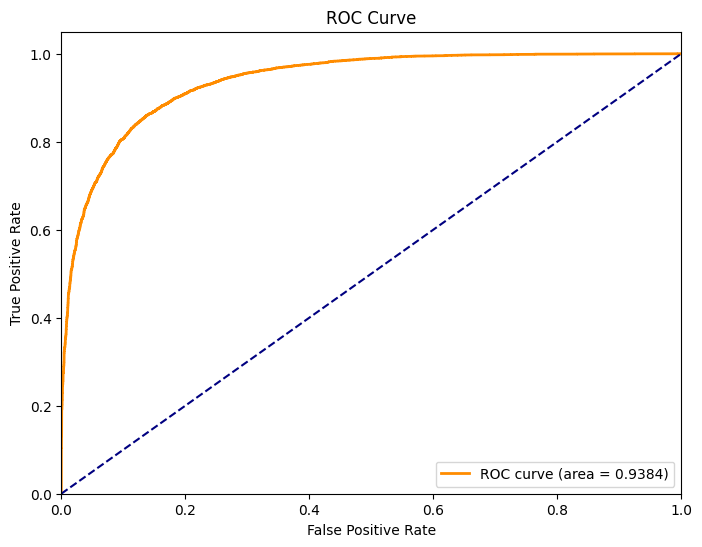

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [13]:
# Оптимизационная функция для Optuna
def objective(trial):
    # Подбор гиперпараметров
    param = {              # Параметры модели LightGBM
        'objective': 'binary',       # Задача классификации с двумя классами
        'metric': 'binary_logloss',  # Метрика для оптимизации — логарифмическая потеря для бинарной классификации
        'verbosity': -1,             # Уровень вывода сообщений (значение -1 отключает вывод)
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),  # Тип алгоритма бустинга, выбираемый среди gbdt, dart и goss
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),  # Количество листьев в дереве, диапазон от 20 до 150
        'max_depth': trial.suggest_int('max_depth', -1, 20),     # Максимальная глубина дерева, диапазон от -1 (без ограничения глубины) до 20
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1),  # Скорость обучения, логарифмически равномерно распределенная между 10^-4 и 1
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),  # Количество деревьев в ансамбле, диапазон от 50 до 500
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # Доля наблюдений для каждого дерева, равномерно распределена между 0.5 и 1.0
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)  # Доля признаков для каждого дерева, равномерно распределена между 0.5 и 1.0
    }

    # Создание и обучение модели
    model = lgb.LGBMClassifier(**param)  # Создаем классификатор LightGBM с подобранными параметрами
    model.fit(X_train, y_train)          # Обучение модели на тренировочных данных

    # Предсказания и оценка
    y_pred = model.predict(X_test)       # Делаем предсказания классов для тестового набора
    y_prob = model.predict_proba(X_test)[:, 1]  # Получаем вероятности для положительного класса

    #recall = recall_score(y_test, y_pred)  # Расчет показателя recall
    #precision = precision_score(y_test, y_pred)  # Расчет точности
    accuracy = accuracy_score(y_test, y_pred)  # Вычисляем точность модели
    #roc_auc = roc_auc_score(y_test, y_prob)  # AUC ROC
    #f1 = f1_score(y_test, y_pred)  # F1 score

    return accuracy  # Возвращаем значение точности как целевой показатель для оптимизации


In [14]:
# Создание исследования Optuna
study = optuna.create_study(direction='maximize')  # Создаем исследование Optuna с целью максимизации целевой функции (в данном случае, точности)
study.optimize(objective, n_trials=30)  # Запускаем процесс оптимизации с использованием нашей целевой функции и проводим 30 экспериментов

[I 2025-03-14 13:20:30,921] A new study created in memory with name: no-name-8e51c344-73b6-45b1-acae-55b5b73d24b1
<ipython-input-13-3160688f34f9>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-4, 1),  # Скорость обучения, логарифмически равномерно распределенная между 10^-4 и 1
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finit

In [15]:
# Вывод результатов
print('Лучшие параметры:', study.best_params)
print('Лучший accuracy:', study.best_value)

Лучшие параметры: {'boosting_type': 'gbdt', 'num_leaves': 45, 'max_depth': 10, 'learning_rate': 0.31512243895712216, 'n_estimators': 397, 'subsample': 0.7258945539382449, 'colsample_bytree': 0.6168912450568473}
Лучший F1-score: 0.8823333333333333


In [16]:
model_X = lgb.LGBMClassifier(**study.best_params, random_state=42)  # Создаем новую модель LightGBM с лучшими параметрами, найденными в результате оптимизации, и задаем начальное случайное состояние для воспроизводимости

In [17]:
# Обучаем модель на тренировочных данных
model_X.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LGBMClassifier(colsample_bytree=0.6168912450568473,
               learning_rate=0.31512243895712216, max_depth=10,
               n_estimators=397, num_leaves=45, random_state=42,
               subsample=0.7258945539382449)

LGBMClassifier(boosting_type='dart', colsample_bytree=0.693778838348271,
               learning_rate=0.47030804211164917, max_depth=0, n_estimators=314,
               num_leaves=118, random_state=42, subsample=0.6965997375026697)

In [18]:
# Получаем предсказания модели на тестовых данных
y_pred = model_X.predict(X_test)
# Получаем вероятности классов для вычисления ROC-AUC
y_prob = model_X.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [19]:
cm1 = confusion_matrix(y_test, y_pred)
print("Матрица ошибок заоптюненой модели:")
print(cm1)

Матрица ошибок заоптюненой модели:
[[6447  964]
 [ 834 6755]]


In [20]:
cr1 = classification_report(y_test, y_pred, target_names=['Класс 0', 'Класс 1'], digits=4)
print("\nОтчёт о классификации заоптюненой модели:")
print(cr1)


Отчёт о классификации заоптюненой модели:
              precision    recall  f1-score   support

     Класс 0     0.8855    0.8699    0.8776      7411
     Класс 1     0.8751    0.8901    0.8825      7589

    accuracy                         0.8801     15000
   macro avg     0.8803    0.8800    0.8801     15000
weighted avg     0.8802    0.8801    0.8801     15000



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


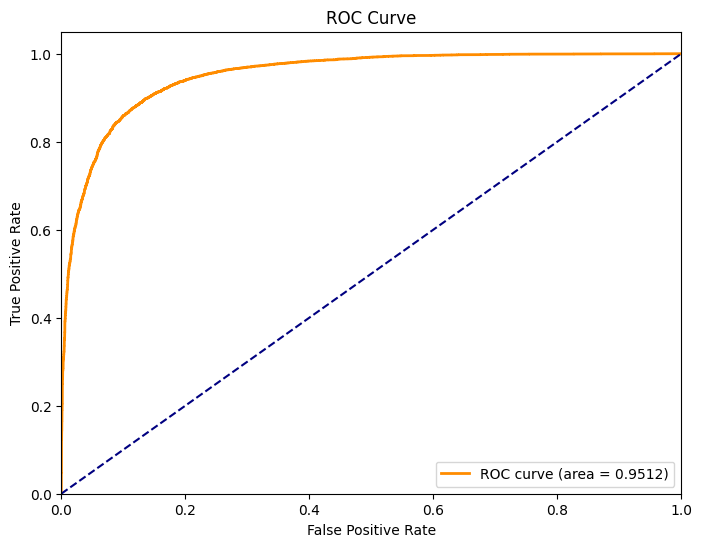

In [23]:

# Получаем вероятности классов для вычисления ROC-AUC
y_prob = model_X.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()